In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col = 'Month')

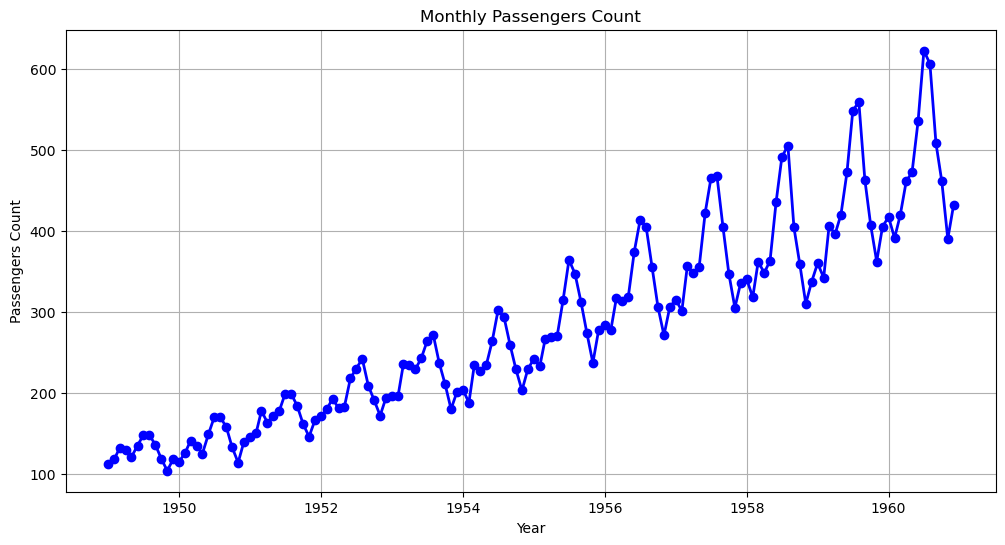

In [3]:
plt.figure(figsize=(12,6))
plt.plot(df,color='blue', marker='o', linestyle="-", linewidth=2, markersize=6)
plt.title('Monthly Passengers Count')
plt.xlabel('Year')
plt.ylabel('Passengers Count')
plt.grid(True)
plt.show()

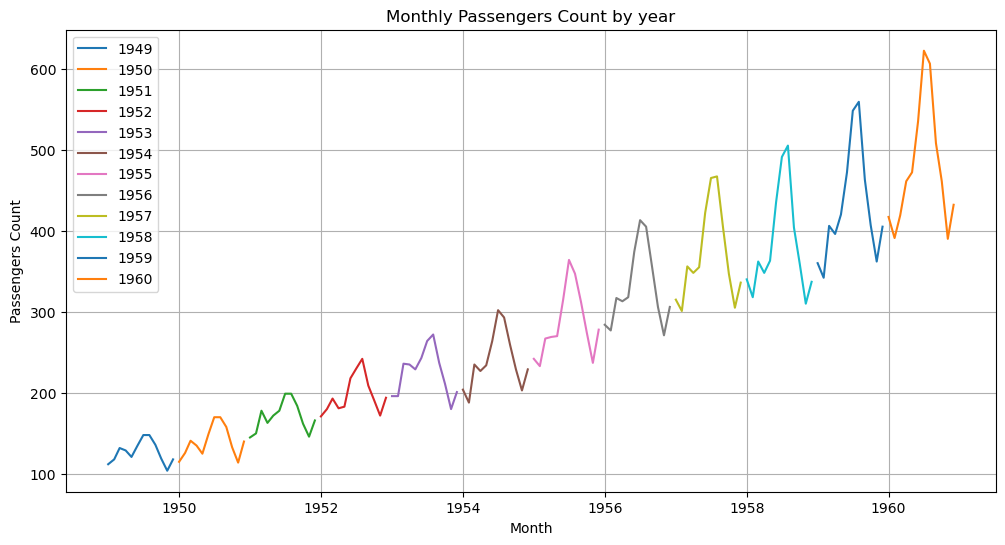

In [4]:
#Extract years from data
years = df.index.year.unique()

plt.figure(figsize=(12,6))
for year in years:
    year_data = df[df.index.year == year]
    plt.plot(year_data, label=year)
plt.title('Monthly Passengers Count by year')
plt.xlabel('Month')
plt.ylabel('Passengers Count')
plt.grid(True)
plt.legend()
plt.show()

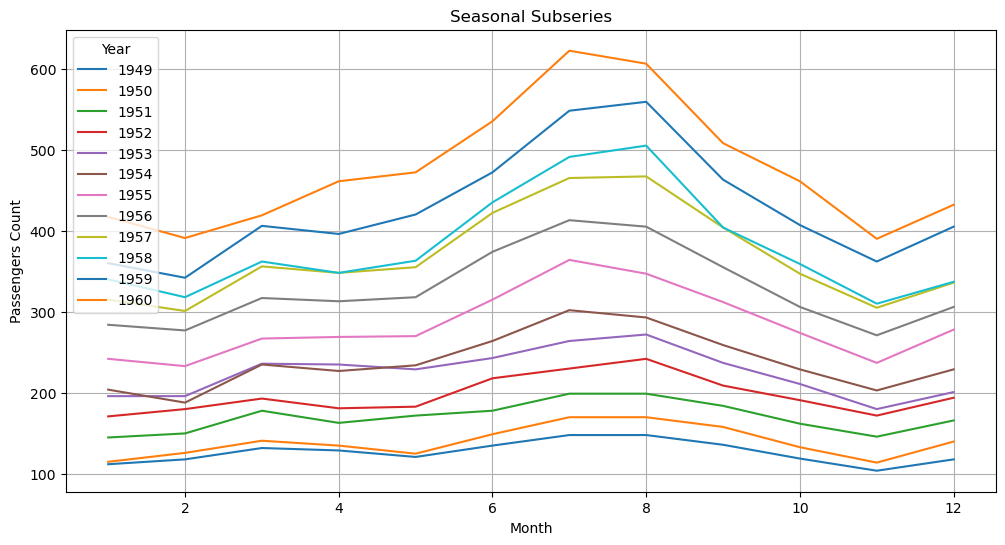

In [5]:
#Plot seasonal subseries
df['Year'] = df.index.year
df['month'] = df.index.month

#Pivot table
table = pd.pivot_table(df, 
                     values='Passengers', 
                     index=['month'], 
                     columns='Year', 
                     aggfunc='sum')

fig, ax = plt.subplots(figsize=(12,6))
table.plot(ax=ax, kind='line',legend=True)
ax.set_xlabel('Month')
ax.set_ylabel('Passengers Count')
ax.set_title('Seasonal Subseries')
plt.grid(True)
plt.show()

In [6]:
import seaborn as sns

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col = 'Month')

C:\Users\luisn\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\luisn\AppData\Local\Temp\ipykernel_4224\3172897795.py:10: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['Passengers'], shade=True)
C:\Users\luisn\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0, 0.5, 'Frecuency')

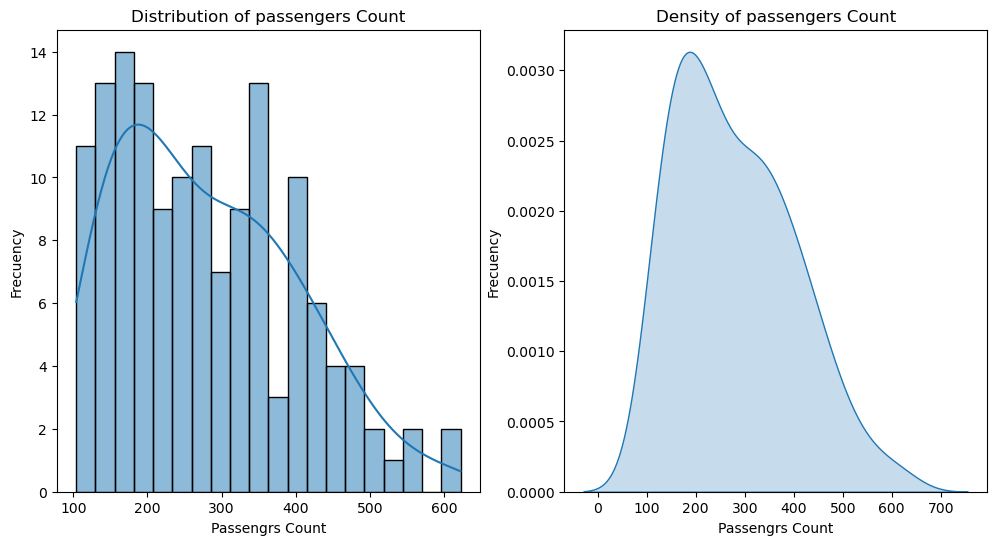

In [7]:
#Histogram
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.histplot(df['Passengers'], bins=20, kde=True)
plt.title('Distribution of passengers Count')
plt.xlabel('Passengrs Count')
plt.ylabel('Frecuency')

plt.subplot(1,2,2)
sns.kdeplot(df['Passengers'], shade=True)
plt.title('Density of passengers Count')
plt.xlabel('Passengrs Count')
plt.ylabel('Frecuency')


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose

In [9]:
np.random.seed(42)
plt.rcParams['figure.figsize'] = (10,4)

In [10]:
def plot_series(s, title):
    s.plot()
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.grid(True)
    plt.show()
    
def adf_test(x):
    res = adfuller(x, autolag="AIC")
    keys = ['test_stat', 'pvalue', 'lags', 'nobs', 'critical_values']
    return dict(zip(keys, [res[0], res[1], res[3], res[4], res[5]]))

def kpss_test(x, regression="c", nlags="auto"):
    stat, pval, lags, crit = kpss(x, regression=regression, nlags = nlags)
    return {"test_stat":stat, "pvalue":pval, "lags":lags, "crit_values": crit}


def print_test(x, name="series"):
    print(f"Test {name}")
    a = adf_test(x)
    print(f"ADF Statistic: {a['test_stat']:.2f} p: {a['pvalue']}")
    try:
        k = kpss_test(x)
        print(f"KPSS: stat={k['test_stat']:.2f} p: {k['pvalue']}")
    except:
        print("KPSS test failed")

def rolling_mean_var(s, window=24, title="Rolling Mean"):
    rolling_mean = s.rolling(window).mean()
    rolling_var = s.rolling(window).var()
    fig, ax = plt.subplots(2, 1, figsize=[10,6])
    ax[0].plot(s, label="Original")
    ax[0].plot(rolling_mean, label="Rolling mean")
    ax[0].legend()
    ax[0].set_title(title + " - mean")
    ax[0].grid(True)
    ax[1].plot(rolling_var, label="Rolling Var")
    ax[1].legend()
    ax[1].set_title(title + " - var")
    plt.show()

In [11]:
n = 240
t = np.arange(n)

#stationary: white noise
white_noise = pd.Series(np.random.normal(0,1,n))

trend = 0.000002 * t
trended = pd.Series(trend + np.random.normal(0,1,n))

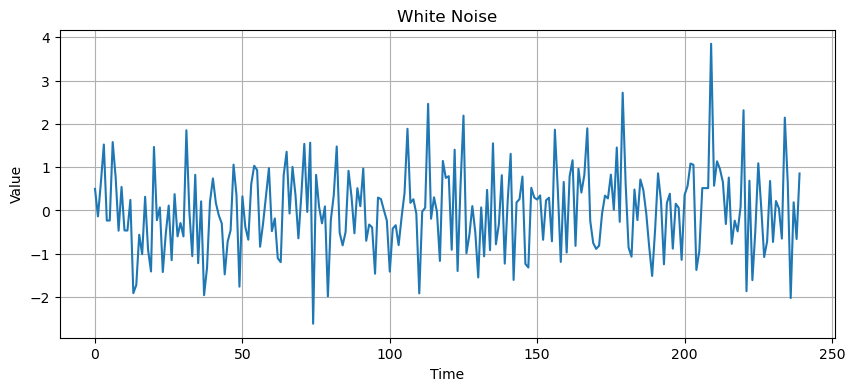

Test White Noise
ADF Statistic: -16.11 p: 5.006520467194035e-29
KPSS: stat=0.30 p: 0.1


C:\Users\luisn\AppData\Local\Temp\ipykernel_4224\1826069395.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, lags, crit = kpss(x, regression=regression, nlags = nlags)


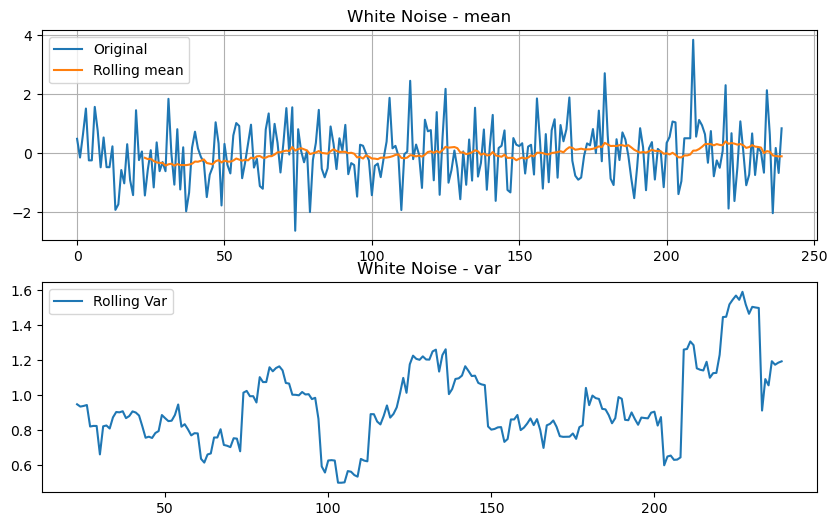

In [12]:
plot_series(white_noise, "White Noise")
print_test(white_noise, "White Noise")
rolling_mean_var(white_noise, window=24, title="White Noise")

In [13]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col = 'Month')
df.head(10)

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136


In [15]:
df.rename(columns={'Passengers':'y'}, inplace=True)
df.head()

,y
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


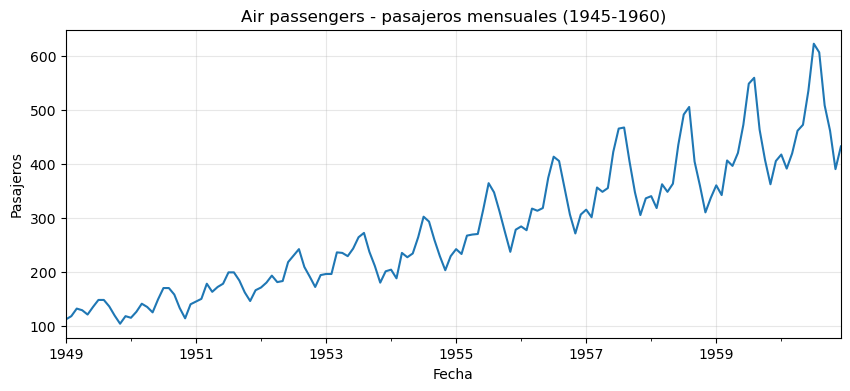

In [16]:
ax = df['y'].plot()
ax.set_title("Air passengers - pasajeros mensuales (1945-1960)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Pasajeros")
ax.grid(True, alpha=0.3)
plt.show()

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose

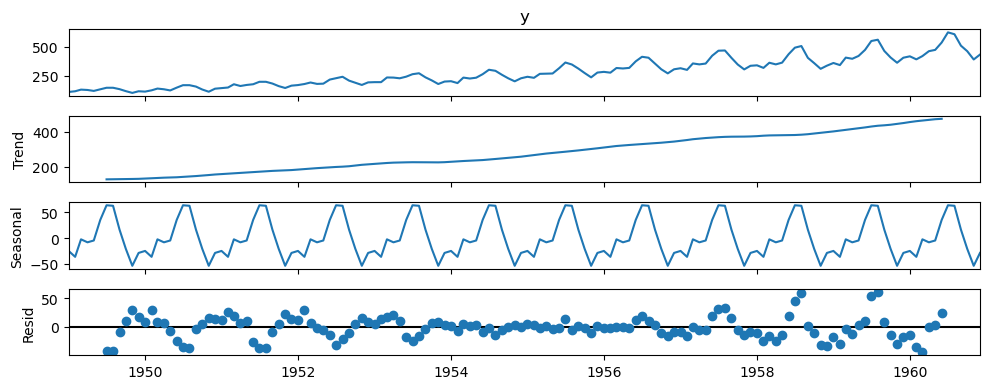

In [18]:
decomp = seasonal_decompose(df['y'], model="additive", period=12)
decomp.plot()
plt.show()